In [ ]:
import pandas as pd
from textblob import TextBlob

In [ ]:
#allowing accesss to my drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/cleaned_dataset(1).csv')

In [ ]:
# Preview the dataset
print(df.head())

        review_id  product_id  \
0   RUE030N50F9EJ  B09PYVXXW5   
1  R385JSD6KWP2QU  B09PYVXXW5   
2  R1UB1V4EPP9MN3  B09PYVXXW5   
3   RWYK1GXIVV6H1  B09PYVXXW5   
4  R3FBQBGQM3II4W  B09PYVXXW5   

                                               title    author  rating  \
0  5.0 out of 5 stars Really good with a couple o...       CTM       5   
1  4.0 out of 5 stars I wish I could rate 5 stars...    Gianna       4   
2  5.0 out of 5 stars Basically perfect, fantasti...  Colin M.       5   
3            1.0 out of 5 stars Decent but Defective    Aquila       1   
4   3.0 out of 5 stars I went with soundcore instead   Frankie       3   

                                             content  \
0  I love TWS earbuds. I have many including buds...   
1  …I just can’t. Because as useful as these earb...   
2  I needed a replacement for my Galaxy buds pro'...   
3  UPDATE 6/24/22: As of 6/23/22, my replacement ...   
4  So out of the box these tiny buds surprised me...   

                   

In [ ]:
# Create new columns for polarity and subjectivity
df['Polarity'] = df['content'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
df['Subjectivity'] = df['content'].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Preview the updated dataset
print(df.head())

        review_id  product_id  \
0   RUE030N50F9EJ  B09PYVXXW5   
1  R385JSD6KWP2QU  B09PYVXXW5   
2  R1UB1V4EPP9MN3  B09PYVXXW5   
3   RWYK1GXIVV6H1  B09PYVXXW5   
4  R3FBQBGQM3II4W  B09PYVXXW5   

                                               title    author  rating  \
0  5.0 out of 5 stars Really good with a couple o...       CTM       5   
1  4.0 out of 5 stars I wish I could rate 5 stars...    Gianna       4   
2  5.0 out of 5 stars Basically perfect, fantasti...  Colin M.       5   
3            1.0 out of 5 stars Decent but Defective    Aquila       1   
4   3.0 out of 5 stars I went with soundcore instead   Frankie       3   

                                             content  \
0  I love TWS earbuds. I have many including buds...   
1  …I just can’t. Because as useful as these earb...   
2  I needed a replacement for my Galaxy buds pro'...   
3  UPDATE 6/24/22: As of 6/23/22, my replacement ...   
4  So out of the box these tiny buds surprised me...   

                   

##Distribution of Polarity Scores

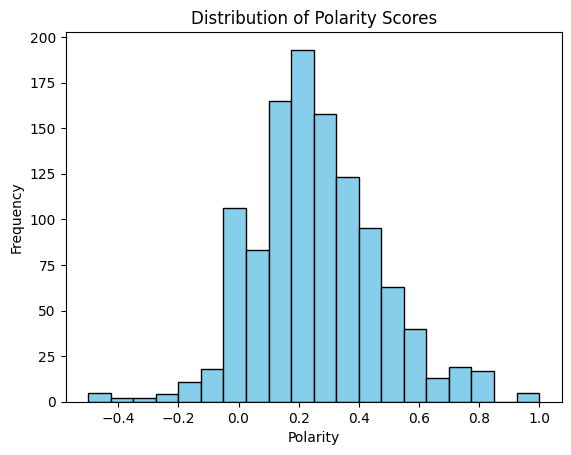

In [ ]:
import matplotlib.pyplot as plt

# Plot histogram of polarity
plt.hist(df['Polarity'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Polarity Scores")
plt.xlabel("Polarity")
plt.ylabel("Frequency")
plt.show()

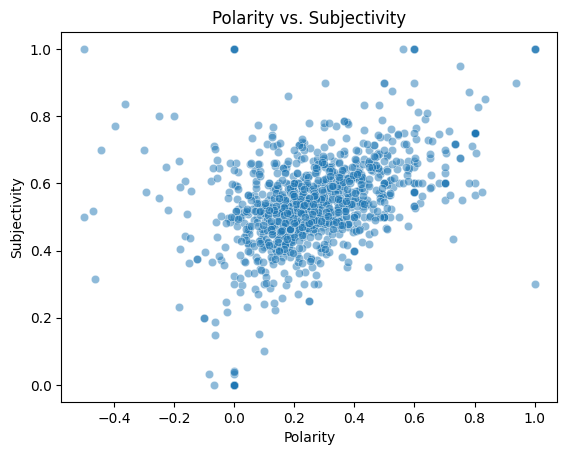

In [ ]:
import seaborn as sns

# Scatter plot
sns.scatterplot(x='Polarity', y='Subjectivity', data=df, alpha=0.5)
plt.title("Polarity vs. Subjectivity")
plt.xlabel("Polarity")
plt.ylabel("Subjectivity")
plt.show()

In [ ]:
def categorize_sentiment(polarity):
    if polarity > 0.2:
        return 'Positive'
    elif polarity < -0.2:
        return 'Negative'
    else:
        return 'Neutral'

# Apply categorization
df['Sentiment'] = df['Polarity'].apply(categorize_sentiment)

# Count the number of each sentiment
print(df['Sentiment'].value_counts())

Sentiment
Positive    656
Neutral     453
Negative     13
Name: count, dtype: int64


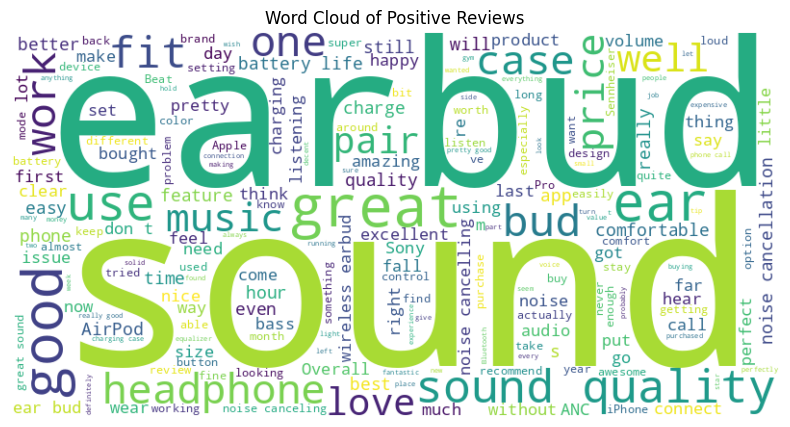

In [ ]:
from wordcloud import WordCloud

# Generate word cloud for positive reviews
positive_reviews = " ".join(df[df['Sentiment'] == 'Positive']['content'])
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(positive_reviews)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Positive Reviews")
plt.show()

In [ ]:
# Save updated dataset
df.to_csv('ear_buds_clean_data.csv', index=False)